# Generate report assets cho project HOG + HSV + SVM / Random Forest

Notebook này dùng để sinh lại toàn bộ asset cho báo cáo theo phiên bản project hiện tại:

1. Thống kê dữ liệu `train / validation / test`.
2. Trực quan hóa pipeline đúng: **ảnh gốc tách thành hai nhánh song song**: nhánh HOG từ ảnh xám và nhánh HSV histogram từ ảnh màu.
3. So sánh HOG `8x2` và `6x3`, đồng thời sinh bảng số chiều `HOG + HSV`.
4. Load 4 model `.joblib` đã train: SVM/RF với cấu hình `6x3` và `8x2`.
5. Đánh giá model trên tập test, sinh bảng kết quả, biểu đồ so sánh, confusion matrix của model tốt nhất.
6. Sinh hình pipeline dự đoán của model tốt nhất.

> Nếu `main.tex` đang dùng `\includegraphics{model_comparison.png}` mà ảnh nằm trong `report_assets`, nên thêm dòng sau vào preamble:
>
> ```latex
> \graphicspath{{report_assets/}}
> ```


## 1. Import thư viện và cấu hình đường dẫn


In [10]:

from __future__ import annotations

import json
import math
import os
import re
import shutil
import warnings
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    """Tự tìm thư mục gốc project dựa vào data/ và models/."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "models").exists():
            return candidate
    return start


# =============================
# CẤU HÌNH CHÍNH
# =============================
# Nếu tự động tìm sai thư mục, hãy mở comment dòng dưới và sửa lại path.
# BASE_DIR = Path(r"E:\Nam_3_HK2\ThiGiac\DoAn\demo")
BASE_DIR = find_project_root(Path.cwd())

DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
ASSETS_DIR = BASE_DIR / "report_assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Nếu main.tex chưa dùng \graphicspath{{report_assets/}}, có thể bật True để copy thêm ảnh ra root project.
COPY_IMAGES_TO_PROJECT_ROOT = False

CLASSES = ["Cam", "Chidan", "Hieulenh", "Nguyhiem", "Phu"]
IMAGE_SIZE = (128, 128)
SEED = 42
VAL_SIZE = 0.2
HSV_HIST_BINS = (16, 8, 8)

MODEL_FILES = {
    "SVM_6x3": MODELS_DIR / "HOG_SVM_6x3.joblib",
    "SVM_8x2": MODELS_DIR / "HOG_SVM_8x2.joblib",
    "RF_6x3": MODELS_DIR / "HOG_RandomForest_6x3.joblib",
    "RF_8x2": MODELS_DIR / "HOG_RandomForest_8x2.joblib",
}

DEFAULT_HOG_PARAMS_8x2 = {
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
    "feature_vector": True,
}

DEFAULT_HOG_PARAMS_6x3 = {
    "orientations": 9,
    "pixels_per_cell": (6, 6),
    "cells_per_block": (3, 3),
    "block_norm": "L2-Hys",
    "feature_vector": True,
}

print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR, "| exists =", DATA_DIR.exists())
print("MODELS_DIR :", MODELS_DIR, "| exists =", MODELS_DIR.exists())
print("ASSETS_DIR :", ASSETS_DIR)

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy thư mục data: {DATA_DIR}")


BASE_DIR   : E:\Nam_3_HK2\ThiGiac\DoAn\demo
DATA_DIR   : E:\Nam_3_HK2\ThiGiac\DoAn\demo\data | exists = True
MODELS_DIR : E:\Nam_3_HK2\ThiGiac\DoAn\demo\models | exists = True
ASSETS_DIR : E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets


## 2. Hàm hỗ trợ: đọc ảnh, HOG, HSV và ghi file


In [11]:

def list_image_files(folder: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])


def normalize_tuple(value, default_value):
    if value is None:
        return tuple(default_value)
    return tuple(value)


def normalize_hog_params(params: dict | None) -> dict:
    params = dict(params or {})
    params.setdefault("orientations", 9)
    params.setdefault("pixels_per_cell", (8, 8))
    params.setdefault("cells_per_block", (2, 2))
    params.setdefault("block_norm", "L2-Hys")
    params.setdefault("feature_vector", True)
    params["pixels_per_cell"] = tuple(params["pixels_per_cell"])
    params["cells_per_block"] = tuple(params["cells_per_block"])
    return params


def to_uint8_rgb(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        image = np.stack([image, image, image], axis=-1)
    if image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]

    rgb = image.astype(np.float32)
    if rgb.max() <= 1.0:
        rgb = rgb * 255.0
    return np.clip(rgb, 0, 255).astype(np.uint8)


def resize_rgb_image(image: np.ndarray, image_size: tuple[int, int]) -> np.ndarray:
    height, width = tuple(image_size)
    rgb = to_uint8_rgb(image)
    return cv2.resize(rgb, (width, height), interpolation=cv2.INTER_AREA)


def load_image_steps(img_path: Path, image_size: tuple[int, int] = IMAGE_SIZE):
    """Trả về ảnh gốc RGB/gray, ảnh xám, ảnh xám resize và ảnh RGB resize."""
    image = imread(img_path)
    if image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]

    if image.ndim == 3:
        gray = rgb2gray(image)
    else:
        gray = image.astype(np.float32)
        if gray.max() > 1:
            gray = gray / 255.0

    gray_resized = resize(gray, image_size, anti_aliasing=True)
    rgb_resized = resize_rgb_image(image, image_size)
    return image, gray, gray_resized, rgb_resized


def extract_hsv_histogram(image: np.ndarray, image_size: tuple[int, int], hsv_bins: tuple[int, int, int]) -> np.ndarray:
    """Trích xuất histogram HSV theo 3 kênh H, S, V rồi nối lại thành vector."""
    rgb_resized = resize_rgb_image(image, image_size)
    hsv = cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2HSV)
    h_bins, s_bins, v_bins = tuple(hsv_bins)

    hist_h = cv2.calcHist([hsv], [0], None, [h_bins], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [s_bins], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [v_bins], [0, 256]).flatten()

    feature = np.concatenate([hist_h, hist_s, hist_v]).astype(np.float32)
    feature /= feature.sum() + 1e-8
    return feature


def enhance_hog_image(hog_image: np.ndarray) -> np.ndarray:
    """Làm ảnh HOG dễ nhìn hơn khi đưa vào báo cáo."""
    image = np.asarray(hog_image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    image = np.maximum(image, 0.0)

    if float(image.max()) <= float(image.min()):
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    active = image[image > 0]
    if active.size == 0:
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    low = float(np.percentile(active, 5.0))
    high = float(np.percentile(active, 99.5))
    if high <= low:
        low, high = 0.0, float(active.max())

    image = np.clip((image - low) / (high - low + 1e-8), 0.0, 1.0)
    image = np.power(image, 0.32)
    image_u8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    image_u8 = cv2.dilate(image_u8, np.ones((2, 2), dtype=np.uint8), iterations=1)

    color_bgr = cv2.applyColorMap(image_u8, cv2.COLORMAP_TURBO)
    color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
    canvas = np.full((*image_u8.shape, 3), 246, dtype=np.uint8)
    mask = image_u8 > 10
    alpha = (image_u8.astype(np.float32) / 255.0)[..., None]
    blended = canvas.astype(np.float32) * (1.0 - alpha) + color_rgb.astype(np.float32) * alpha
    canvas[mask] = blended[mask].astype(np.uint8)
    return canvas


def extract_hog_visual(gray_resized: np.ndarray, hog_params: dict):
    hog_params = normalize_hog_params(hog_params)
    fd, hog_img = hog(gray_resized, visualize=True, **hog_params)
    return fd.astype(np.float32), enhance_hog_image(hog_img)


def build_feature_from_path(img_path: Path, hog_params: dict, image_size: tuple[int, int], hsv_bins=None) -> np.ndarray:
    """
    Pipeline đúng:
    - Nhánh 1: ảnh -> grayscale -> resize -> HOG vector.
    - Nhánh 2: ảnh màu -> resize RGB -> HSV histogram.
    - Sau đó nối hai vector lại.
    """
    image, _, gray_resized, _ = load_image_steps(img_path, image_size)
    hog_feature = hog(gray_resized, **normalize_hog_params(hog_params)).astype(np.float32)

    if hsv_bins is None:
        return hog_feature

    hsv_feature = extract_hsv_histogram(image, image_size, tuple(hsv_bins))
    return np.concatenate([hog_feature, hsv_feature]).astype(np.float32)


def save_text(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")


def save_fig(fig, filename: str, dpi: int = 300):
    path = ASSETS_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    if COPY_IMAGES_TO_PROJECT_ROOT and path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        shutil.copy2(path, BASE_DIR / filename)
    print("Đã lưu:", path)
    return path


def df_to_latex(df: pd.DataFrame, filename: str, **kwargs):
    path = ASSETS_DIR / filename
    default = dict(index=False, escape=False)
    default.update(kwargs)
    save_text(path, df.to_latex(**default))
    print("Đã lưu:", path)
    return path


def choose_sample(preferred_label: str = "Nguyhiem") -> Path:
    labels = [preferred_label] + [c for c in CLASSES if c != preferred_label]
    for cls in labels:
        candidates = list_image_files(DATA_DIR / "test" / cls)
        if candidates:
            return candidates[0]
    for cls in labels:
        candidates = list_image_files(DATA_DIR / "train" / cls)
        if candidates:
            return candidates[0]
    raise FileNotFoundError("Không tìm thấy ảnh mẫu trong data/train hoặc data/test.")


## 3. Thống kê train / validation / test


      Lớp  Train  Validation  Test  Tổng
      Cam    490         123    68   681
   Chidan    454         113    63   630
 Hieulenh    470         117    65   652
 Nguyhiem    473         118    66   657
      Phu    297          75    41   413
Tổng cộng   2184         546   303  3033
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\data_counts.tex
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\data_distribution.png


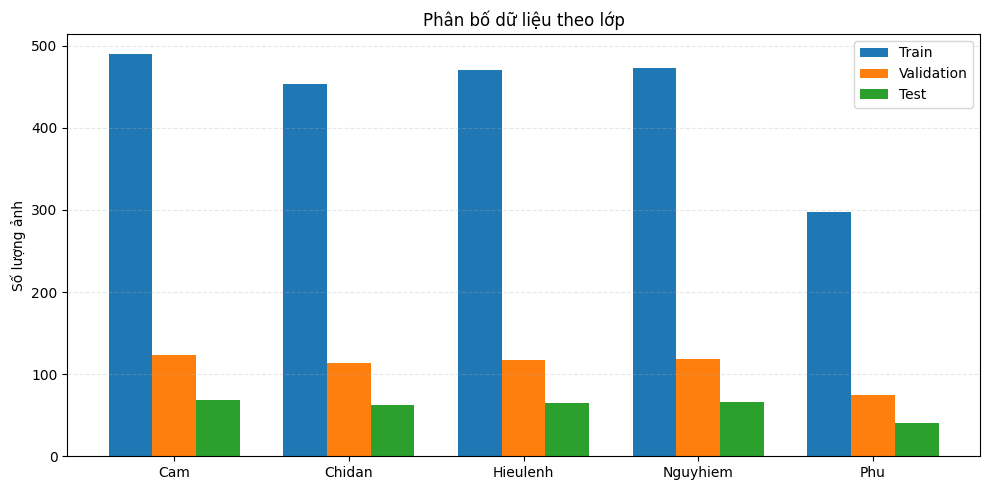

In [12]:

def collect_samples(split: str) -> list[tuple[Path, str]]:
    samples = []
    for cls in CLASSES:
        for img_path in list_image_files(DATA_DIR / split / cls):
            samples.append((img_path, cls))
    return samples


train_full_samples = collect_samples("train")
test_samples = collect_samples("test")

if not train_full_samples:
    raise FileNotFoundError(f"Không tìm thấy ảnh train trong {DATA_DIR / 'train'}")

train_full_paths = [p for p, _ in train_full_samples]
train_full_labels = [y for _, y in train_full_samples]

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_full_paths,
    train_full_labels,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_full_labels,
)

train_samples = list(zip(train_paths, train_labels))
val_samples = list(zip(val_paths, val_labels))

rows = []
for cls in CLASSES:
    rows.append({
        "Lớp": cls,
        "Train": sum(y == cls for _, y in train_samples),
        "Validation": sum(y == cls for _, y in val_samples),
        "Test": sum(y == cls for _, y in test_samples),
    })

stats_df = pd.DataFrame(rows)
stats_df["Tổng"] = stats_df[["Train", "Validation", "Test"]].sum(axis=1)
stats_df.loc[len(stats_df)] = {
    "Lớp": "Tổng cộng",
    "Train": int(stats_df["Train"].sum()),
    "Validation": int(stats_df["Validation"].sum()),
    "Test": int(stats_df["Test"].sum()),
    "Tổng": int(stats_df["Tổng"].sum()),
}

print(stats_df.to_string(index=False))
df_to_latex(stats_df, "data_counts.tex")

# Biểu đồ phân bố dữ liệu theo lớp
plot_df = stats_df[stats_df["Lớp"] != "Tổng cộng"].copy()
x = np.arange(len(plot_df))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, plot_df["Train"], width, label="Train")
ax.bar(x, plot_df["Validation"], width, label="Validation")
ax.bar(x + width, plot_df["Test"], width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Lớp"])
ax.set_ylabel("Số lượng ảnh")
ax.set_title("Phân bố dữ liệu theo lớp")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
save_fig(fig, "data_distribution.png")
plt.show()
plt.close(fig)


## 4. Trực quan hóa pipeline HOG + HSV và số chiều đặc trưng


Ảnh mẫu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\data\test\Nguyhiem\Nguyhiem_001.jpg
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\feature_pipeline_hog_hsv.png


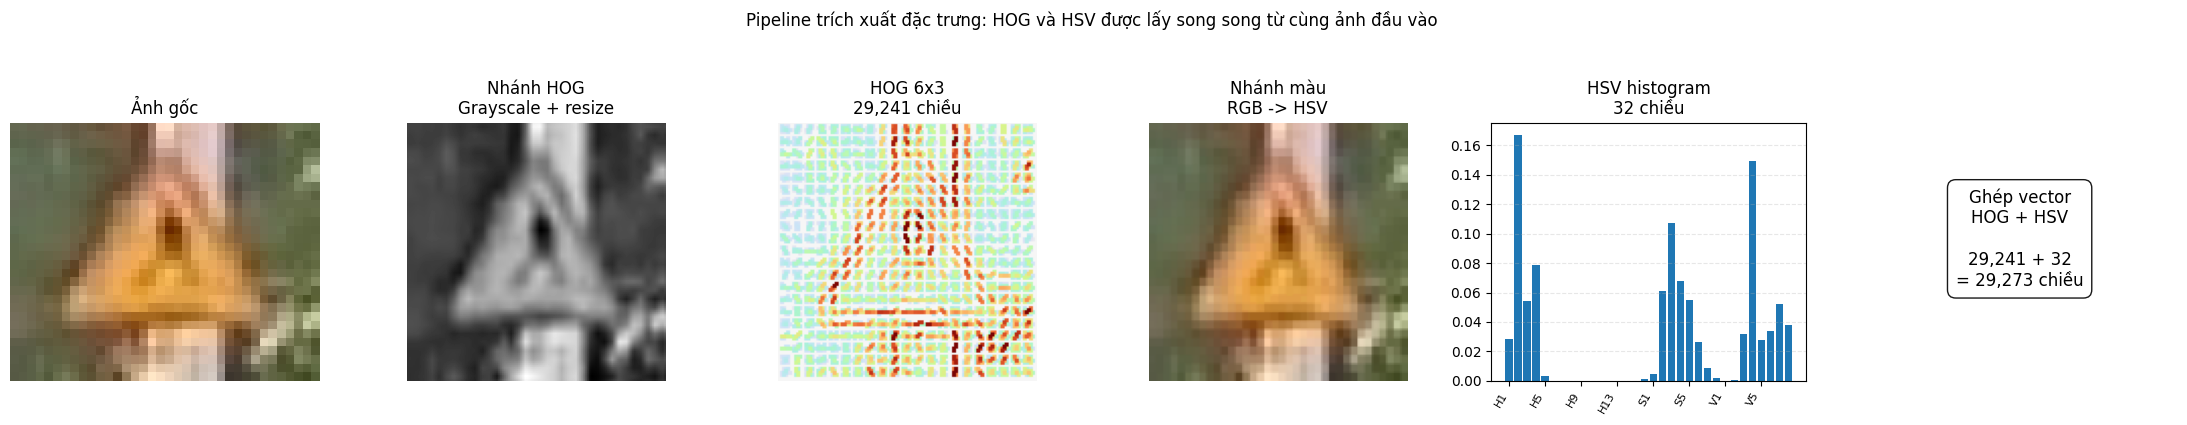

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\hog_feature_compare.png


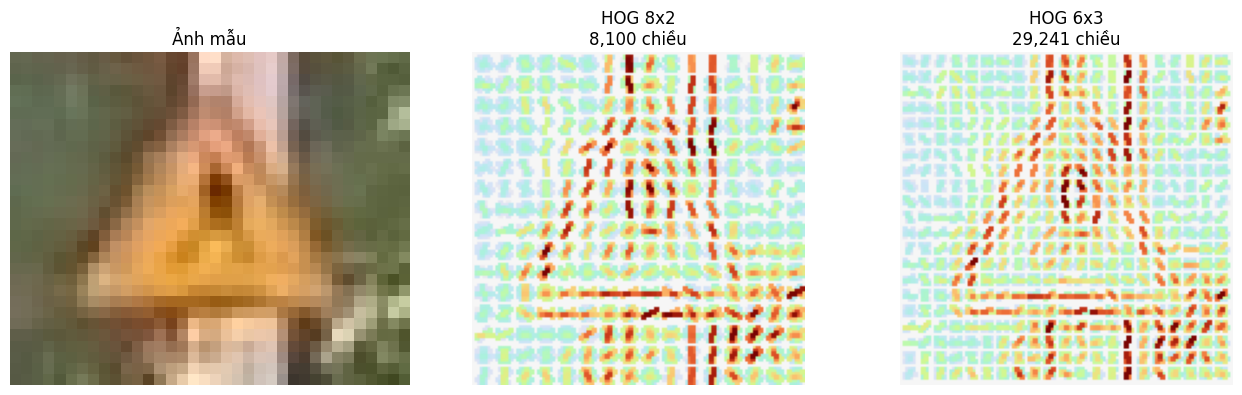

     Cấu hình   HOG  HSV  Tổng số chiều pixels_per_cell cells_per_block
HOG + HSV 8x2  8100   32           8132          (8, 8)          (2, 2)
HOG + HSV 6x3 29241   32          29273          (6, 6)          (3, 3)
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\hog_hsv_feature_dimensions.tex
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\hog_feature_dimensions.tex


In [13]:

def make_hsv_bin_labels(hsv_bins: tuple[int, int, int]) -> list[str]:
    return (
        [f"H{i+1}" for i in range(hsv_bins[0])] +
        [f"S{i+1}" for i in range(hsv_bins[1])] +
        [f"V{i+1}" for i in range(hsv_bins[2])]
    )


def plot_feature_pipeline(sample_path: Path):
    image, gray, gray_resized, rgb_resized = load_image_steps(sample_path, IMAGE_SIZE)
    hog_fd, hog_img = extract_hog_visual(gray_resized, DEFAULT_HOG_PARAMS_6x3)
    hsv_feature = extract_hsv_histogram(image, IMAGE_SIZE, HSV_HIST_BINS)
    hsv_img = cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2HSV)
    hsv_for_show = cv2.cvtColor(hsv_img, cv2.COLOR_HSV2RGB)
    combined_dim = len(hog_fd) + len(hsv_feature)

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    axes[0].imshow(image, cmap="gray" if image.ndim == 2 else None)
    axes[0].set_title("Ảnh gốc")
    axes[1].imshow(gray_resized, cmap="gray")
    axes[1].set_title("Nhánh HOG\nGrayscale + resize")
    axes[2].imshow(hog_img)
    axes[2].set_title(f"HOG 6x3\n{len(hog_fd):,} chiều")
    axes[3].imshow(hsv_for_show)
    axes[3].set_title("Nhánh màu\nRGB -> HSV")

    labels = make_hsv_bin_labels(HSV_HIST_BINS)
    axes[4].bar(np.arange(len(hsv_feature)), hsv_feature)
    axes[4].set_title(f"HSV histogram\n{len(hsv_feature):,} chiều")
    axes[4].set_xticks(np.arange(len(hsv_feature))[::4])
    axes[4].set_xticklabels(labels[::4], rotation=60, ha="right", fontsize=8)
    axes[4].grid(axis="y", linestyle="--", alpha=0.3)

    axes[5].axis("off")
    axes[5].text(
        0.5,
        0.55,
        "Ghép vector\nHOG + HSV\n\n"
        f"{len(hog_fd):,} + {len(hsv_feature):,}\n"
        f"= {combined_dim:,} chiều",
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9),
    )

    for ax in axes[:4]:
        ax.axis("off")

    fig.suptitle("Pipeline trích xuất đặc trưng: HOG và HSV được lấy song song từ cùng ảnh đầu vào", y=1.05)
    plt.tight_layout()
    save_fig(fig, "feature_pipeline_hog_hsv.png")
    plt.show()
    plt.close(fig)


def plot_hog_compare_and_feature_dims(sample_path: Path):
    image, gray, gray_resized, _ = load_image_steps(sample_path, IMAGE_SIZE)

    fd_8x2, hog_img_8x2 = extract_hog_visual(gray_resized, DEFAULT_HOG_PARAMS_8x2)
    fd_6x3, hog_img_6x3 = extract_hog_visual(gray_resized, DEFAULT_HOG_PARAMS_6x3)
    hsv_dim = sum(HSV_HIST_BINS)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(image, cmap="gray" if image.ndim == 2 else None)
    axes[0].set_title("Ảnh mẫu")
    axes[1].imshow(hog_img_8x2)
    axes[1].set_title(f"HOG 8x2\n{len(fd_8x2):,} chiều")
    axes[2].imshow(hog_img_6x3)
    axes[2].set_title(f"HOG 6x3\n{len(fd_6x3):,} chiều")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    save_fig(fig, "hog_feature_compare.png")
    plt.show()
    plt.close(fig)

    dim_df = pd.DataFrame([
        {
            "Cấu hình": "HOG + HSV 8x2",
            "HOG": len(fd_8x2),
            "HSV": hsv_dim,
            "Tổng số chiều": len(fd_8x2) + hsv_dim,
            "pixels_per_cell": str(DEFAULT_HOG_PARAMS_8x2["pixels_per_cell"]),
            "cells_per_block": str(DEFAULT_HOG_PARAMS_8x2["cells_per_block"]),
        },
        {
            "Cấu hình": "HOG + HSV 6x3",
            "HOG": len(fd_6x3),
            "HSV": hsv_dim,
            "Tổng số chiều": len(fd_6x3) + hsv_dim,
            "pixels_per_cell": str(DEFAULT_HOG_PARAMS_6x3["pixels_per_cell"]),
            "cells_per_block": str(DEFAULT_HOG_PARAMS_6x3["cells_per_block"]),
        },
    ])
    print(dim_df.to_string(index=False))
    df_to_latex(dim_df, "hog_hsv_feature_dimensions.tex")
    # Alias cũ nếu main.tex đang input bảng cũ.
    df_to_latex(dim_df, "hog_feature_dimensions.tex")


sample_img = choose_sample("Nguyhiem")
print("Ảnh mẫu:", sample_img)
plot_feature_pipeline(sample_img)
plot_hog_compare_and_feature_dims(sample_img)


## 5. Load model và đánh giá trên tập test


In [14]:

def infer_config_from_key(model_key: str) -> str:
    return "6x3" if "6x3" in model_key else "8x2"


def infer_algorithm_from_key(model_key: str) -> str:
    return "Random Forest" if model_key.startswith("RF") or "RF" in model_key else "SVM"


def get_default_hog_from_key(model_key: str) -> dict:
    return DEFAULT_HOG_PARAMS_6x3 if infer_config_from_key(model_key) == "6x3" else DEFAULT_HOG_PARAMS_8x2


def make_display_name(model_key: str, hsv_bins) -> str:
    algo = infer_algorithm_from_key(model_key)
    config = infer_config_from_key(model_key)
    feature_name = "HOG + HSV" if hsv_bins is not None else "HOG"
    return f"{feature_name} + {algo} {config}"


def load_model_package(model_key: str, model_path: Path) -> dict:
    payload = joblib.load(model_path)
    if isinstance(payload, dict):
        model = payload.get("model")
        label_encoder = payload.get("label_encoder")
        hog_params = payload.get("hog_params")
        hsv_bins = payload.get("hsv_hist_bins")
        image_size = payload.get("image_size", IMAGE_SIZE)
        classes = payload.get("classes")
        feature_extractor = payload.get("feature_extractor")
    else:
        model = payload
        label_encoder = None
        hog_params = get_default_hog_from_key(model_key)
        hsv_bins = None
        image_size = IMAGE_SIZE
        classes = CLASSES
        feature_extractor = "HOG"

    if model is None:
        raise ValueError("Payload không có key 'model'.")

    if hasattr(model, "n_jobs"):
        # Giảm lỗi song song trên một số môi trường Windows/Jupyter khi predict.
        model.n_jobs = 1

    hog_params = normalize_hog_params(hog_params or get_default_hog_from_key(model_key))
    hsv_bins = None if hsv_bins is None else normalize_tuple(hsv_bins, HSV_HIST_BINS)
    image_size = normalize_tuple(image_size, IMAGE_SIZE)

    if classes is None and label_encoder is not None:
        classes = list(label_encoder.classes_)
    if classes is None:
        classes = CLASSES

    return {
        "key": model_key,
        "path": model_path,
        "payload": payload,
        "model": model,
        "label_encoder": label_encoder,
        "hog_params": hog_params,
        "hsv_bins": hsv_bins,
        "image_size": image_size,
        "classes": [str(c) for c in classes],
        "feature_extractor": feature_extractor,
        "display_name": make_display_name(model_key, hsv_bins),
    }


def encode_labels(labels_text: list[str], label_encoder, class_names: list[str]):
    if label_encoder is not None:
        known_labels = set(label_encoder.classes_)
        keep_idx = [i for i, y in enumerate(labels_text) if y in known_labels]
        y_true = label_encoder.transform([labels_text[i] for i in keep_idx])
        report_labels = np.arange(len(label_encoder.classes_))
        report_names = [str(c) for c in label_encoder.classes_]
        return y_true, keep_idx, report_labels, report_names

    keep_idx = list(range(len(labels_text)))
    y_true = np.array(labels_text)
    report_labels = class_names
    report_names = class_names
    return y_true, keep_idx, report_labels, report_names


def evaluate_package_on_samples(pkg: dict, samples: list[tuple[Path, str]], split_name: str) -> dict:
    features = []
    labels_text = []
    skipped = []

    for img_path, label in samples:
        try:
            feat = build_feature_from_path(img_path, pkg["hog_params"], pkg["image_size"], pkg["hsv_bins"])
            features.append(feat)
            labels_text.append(label)
        except Exception as exc:
            skipped.append((img_path, str(exc)))

    if not features:
        raise RuntimeError(f"Không trích xuất được feature nào cho split {split_name}.")

    X = np.vstack(features)
    expected_dim = getattr(pkg["model"], "n_features_in_", None)
    if expected_dim is not None and X.shape[1] != expected_dim:
        raise ValueError(
            f"Sai số chiều feature ở {pkg['display_name']}: tạo được {X.shape[1]}, model cần {expected_dim}."
        )

    y_true, keep_idx, report_labels, report_names = encode_labels(labels_text, pkg["label_encoder"], pkg["classes"])
    X = X[keep_idx]
    labels_text = [labels_text[i] for i in keep_idx]

    y_pred = pkg["model"].predict(X)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    report_text = classification_report(
        y_true,
        y_pred,
        labels=report_labels,
        target_names=report_names,
        digits=4,
        zero_division=0,
    )

    return {
        **pkg,
        "split": split_name,
        "X": X,
        "y_true": y_true,
        "y_pred": y_pred,
        "labels_text": labels_text,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "report_text": report_text,
        "n_samples": len(labels_text),
        "n_skipped": len(skipped),
        "skipped": skipped,
    }


if not test_samples:
    raise FileNotFoundError(f"Không tìm thấy ảnh test trong {DATA_DIR / 'test'}")

print(f"Số ảnh test: {len(test_samples)}")
print(pd.Series([label for _, label in test_samples]).value_counts().sort_index().to_string())

loaded_packages = {}
model_eval_details = {}
failed_models = {}
rows = []
best_model_data = None
best_score = -np.inf

for model_key, model_path in MODEL_FILES.items():
    print("\n" + "=" * 80)
    print("Đánh giá:", model_key, "|", model_path.name)

    try:
        pkg = load_model_package(model_key, model_path)
        loaded_packages[model_key] = pkg
        info = evaluate_package_on_samples(pkg, test_samples, "test")
    except Exception as exc:
        failed_models[model_key] = str(exc)
        print("Lỗi:", exc)
        continue

    print(info["report_text"])
    save_text(ASSETS_DIR / f"classification_report_{model_key}.txt", info["report_text"])
    model_eval_details[model_key] = info

    rows.append({
        "Mô hình": info["display_name"],
        "Accuracy": round(info["accuracy"], 4),
        "Macro F1-score": round(info["macro_f1"], 4),
        "Weighted F1-score": round(info["weighted_f1"], 4),
        "Samples": info["n_samples"],
    })

    if info["accuracy"] > best_score:
        best_score = info["accuracy"]
        best_model_data = info

results_df = pd.DataFrame(rows)
if not results_df.empty:
    results_df = results_df.sort_values(["Accuracy", "Weighted F1-score"], ascending=False).reset_index(drop=True)

print("\nBảng kết quả test:")
try:
    display(results_df)
except NameError:
    print(results_df.to_string(index=False))

df_to_latex(results_df, "model_comparison.tex")

if failed_models:
    print("\nModel bị lỗi / thiếu file:")
    for name, reason in failed_models.items():
        print(f"- {name}: {reason}")

if best_model_data is not None:
    print(f"\nModel tốt nhất: {best_model_data['display_name']} | Accuracy = {best_score:.4f}")
    save_text(
        ASSETS_DIR / "best_model_summary.tex",
        f"\\textbf{{{best_model_data['display_name']}}} đạt Accuracy \\textbf{{{best_score:.4f}}} trên tập test."
    )


Số ảnh test: 303
Cam         68
Chidan      63
Hieulenh    65
Nguyhiem    66
Phu         41

Đánh giá: SVM_6x3 | HOG_SVM_6x3.joblib
              precision    recall  f1-score   support

         Cam     0.9559    0.9559    0.9559        68
      Chidan     0.8333    0.8730    0.8527        63
    Hieulenh     0.9000    0.8308    0.8640        65
    Nguyhiem     0.9851    1.0000    0.9925        66
         Phu     0.7857    0.8049    0.7952        41

    accuracy                         0.9010       303
   macro avg     0.8920    0.8929    0.8921       303
weighted avg     0.9017    0.9010    0.9009       303


Đánh giá: SVM_8x2 | HOG_SVM_8x2.joblib
              precision    recall  f1-score   support

         Cam     0.9706    0.9706    0.9706        68
      Chidan     0.8028    0.9048    0.8507        63
    Hieulenh     0.9167    0.8462    0.8800        65
    Nguyhiem     0.9851    1.0000    0.9925        66
         Phu     0.8919    0.8049    0.8462        41

    accuracy 

,Mô hình,Accuracy,Macro F1-score,Weighted F1-score,Samples
0,HOG + HSV + SVM 8x2,0.9142,0.9080,0.9142,303
1,HOG + HSV + Random Forest 8x2,0.9109,0.9059,0.9106,303
2,HOG + HSV + SVM 6x3,0.9010,0.8921,0.9009,303
3,HOG + HSV + Random Forest 6x3,0.8878,0.8821,0.8875,303


Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\model_comparison.tex

Model tốt nhất: HOG + HSV + SVM 8x2 | Accuracy = 0.9142


## 6. Sinh bảng tham số của các model đã lưu


In [15]:

def compact_params_for_report(pkg: dict) -> str:
    model = pkg["model"]
    params = model.get_params() if hasattr(model, "get_params") else {}
    algo = infer_algorithm_from_key(pkg["key"])

    if algo == "SVM":
        keys = ["kernel", "C", "gamma", "class_weight", "shrinking"]
    else:
        keys = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]

    parts = []
    for key in keys:
        if key in params:
            val = params[key]
            if isinstance(val, float):
                val = round(val, 4)
            parts.append(f"{key}={val}")
    return ", ".join(parts)


param_rows = []
for key, pkg in loaded_packages.items():
    expected_dim = getattr(pkg["model"], "n_features_in_", "")
    param_rows.append({
        "Mô hình": pkg["display_name"],
        "Feature extractor": pkg.get("feature_extractor") or ("HOG_HSV" if pkg["hsv_bins"] is not None else "HOG"),
        "HOG pixels/cell": str(pkg["hog_params"].get("pixels_per_cell")),
        "HOG cells/block": str(pkg["hog_params"].get("cells_per_block")),
        "HSV bins": "-" if pkg["hsv_bins"] is None else str(pkg["hsv_bins"]),
        "Số chiều": expected_dim,
        "Tham số model": compact_params_for_report(pkg),
    })

params_df = pd.DataFrame(param_rows)
print(params_df.to_string(index=False))
df_to_latex(params_df, "model_params.tex")


                      Mô hình Feature extractor HOG pixels/cell HOG cells/block   HSV bins  Số chiều                                                                              Tham số model
          HOG + HSV + SVM 6x3           HOG_HSV          (6, 6)          (3, 3) (16, 8, 8)     29273                   kernel=linear, C=7.3561, gamma=scale, class_weight=None, shrinking=False
          HOG + HSV + SVM 8x2           HOG_HSV          (8, 8)          (2, 2) (16, 8, 8)      8132               kernel=linear, C=0.0358, gamma=scale, class_weight=balanced, shrinking=False
HOG + HSV + Random Forest 6x3           HOG_HSV          (6, 6)          (3, 3) (16, 8, 8)     29273 n_estimators=200, max_depth=45, min_samples_split=9, min_samples_leaf=3, max_features=sqrt
HOG + HSV + Random Forest 8x2           HOG_HSV          (8, 8)          (2, 2) (16, 8, 8)      8132 n_estimators=200, max_depth=21, min_samples_split=4, min_samples_leaf=2, max_features=sqrt
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\r

WindowsPath('E:/Nam_3_HK2/ThiGiac/DoAn/demo/report_assets/model_params.tex')

## 7. Vẽ biểu đồ so sánh và confusion matrix của model tốt nhất


Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\model_comparison.png


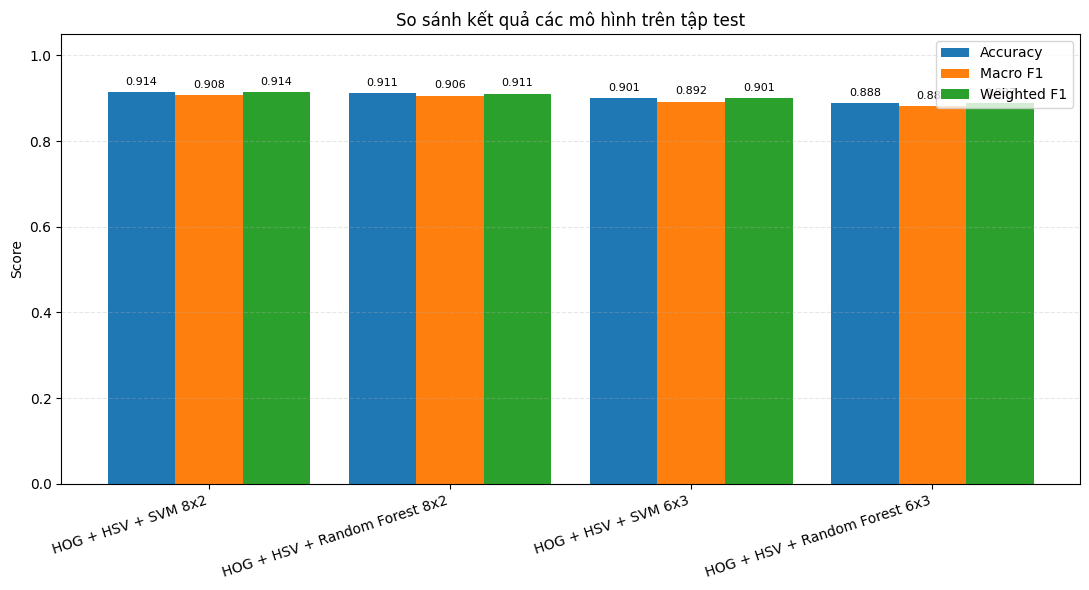

Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\confusion_matrix_best.png


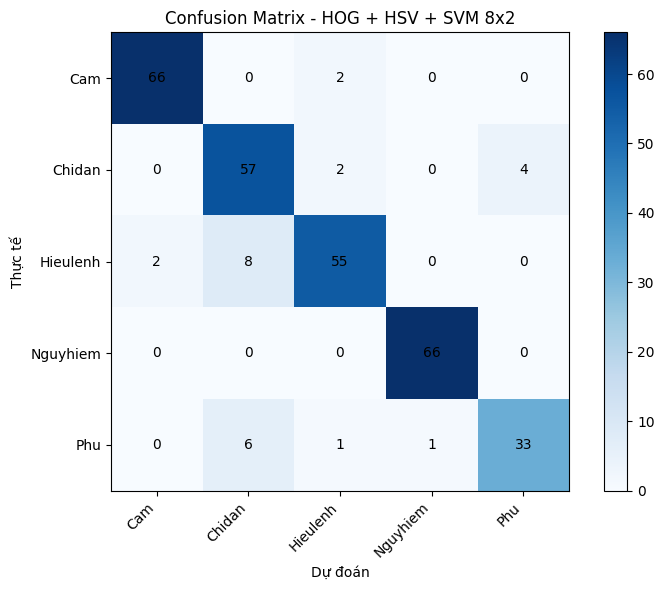

In [16]:

if not results_df.empty:
    x = np.arange(len(results_df))
    width = 0.28

    fig, ax = plt.subplots(figsize=(11, 6))
    bars_acc = ax.bar(x - width, results_df["Accuracy"], width=width, label="Accuracy")
    bars_macro = ax.bar(x, results_df["Macro F1-score"], width=width, label="Macro F1")
    bars_weighted = ax.bar(x + width, results_df["Weighted F1-score"], width=width, label="Weighted F1")

    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Mô hình"], rotation=18, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("So sánh kết quả các mô hình trên tập test")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    for bars in [bars_acc, bars_macro, bars_weighted]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.012,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.tight_layout()
    save_fig(fig, "model_comparison.png")
    plt.show()
    plt.close(fig)
else:
    print("Không có kết quả để vẽ model_comparison.png")


if best_model_data is not None:
    cm = confusion_matrix(best_model_data["y_true"], best_model_data["y_pred"])
    class_names = best_model_data["classes"]
    if best_model_data["label_encoder"] is not None:
        class_names = [str(c) for c in best_model_data["label_encoder"].classes_]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
    ax.set_title(f"Confusion Matrix - {best_model_data['display_name']}")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    plt.tight_layout()
    save_fig(fig, "confusion_matrix_best.png")
    plt.show()
    plt.close(fig)
else:
    print("Không có best_model_data để vẽ confusion matrix.")


## 8. Sinh ảnh pipeline dự đoán của model tốt nhất


Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\pipeline_best.png
Đã lưu: E:\Nam_3_HK2\ThiGiac\DoAn\demo\report_assets\prediction_pipeline_SVM_8x2.png


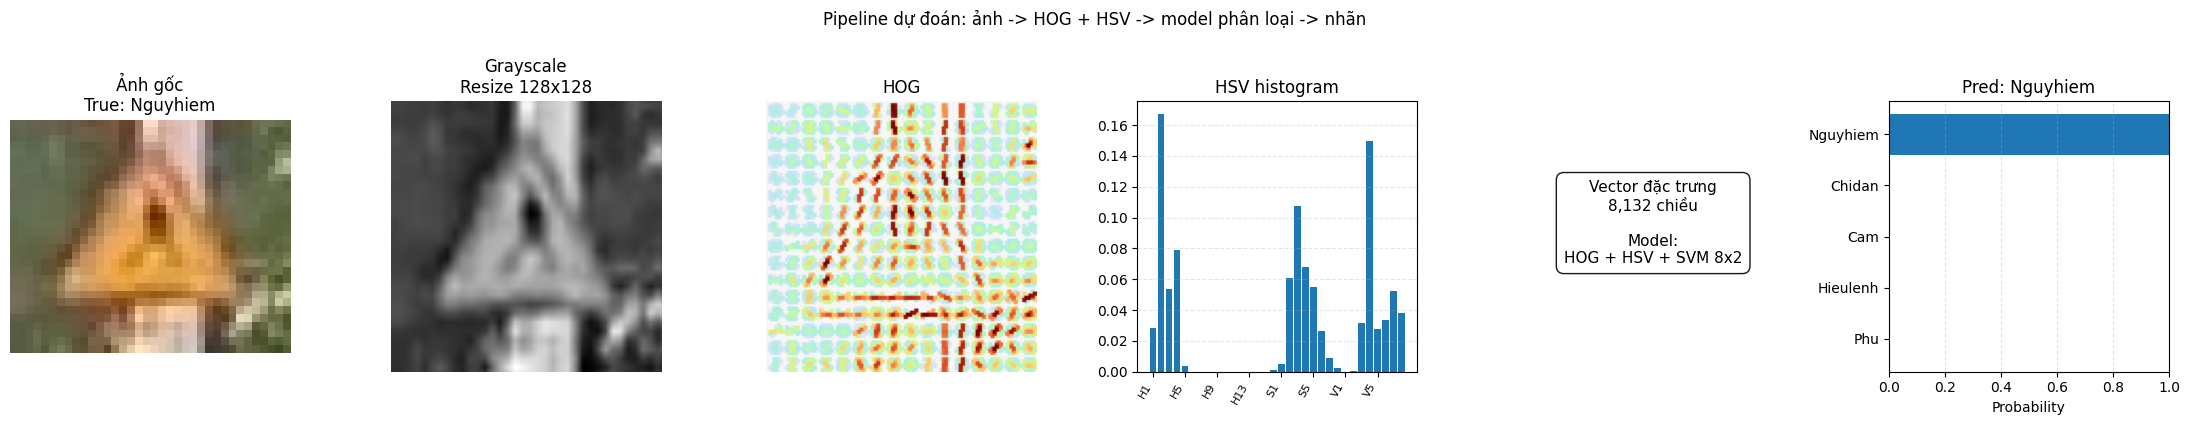

In [17]:

def predict_one_with_package(pkg: dict, img_path: Path):
    image, gray, gray_resized, _ = load_image_steps(img_path, pkg["image_size"])
    hog_fd, hog_img = extract_hog_visual(gray_resized, pkg["hog_params"])
    hsv_fd = None
    if pkg["hsv_bins"] is not None:
        hsv_fd = extract_hsv_histogram(image, pkg["image_size"], pkg["hsv_bins"])
    feature = build_feature_from_path(img_path, pkg["hog_params"], pkg["image_size"], pkg["hsv_bins"]).reshape(1, -1)

    pred = pkg["model"].predict(feature)[0]
    if pkg["label_encoder"] is not None:
        pred_label = pkg["label_encoder"].inverse_transform([pred])[0]
        class_names = [str(c) for c in pkg["label_encoder"].classes_]
    else:
        pred_label = str(pred)
        class_names = pkg["classes"]

    proba = None
    if hasattr(pkg["model"], "predict_proba"):
        try:
            proba = pkg["model"].predict_proba(feature)[0]
        except Exception:
            proba = None

    return image, gray_resized, hog_img, hsv_fd, feature, str(pred_label), class_names, proba


def plot_prediction_pipeline_best(best_info: dict):
    if best_info is None:
        print("Không có best model để sinh pipeline_best.png")
        return

    sample_path = choose_sample("Nguyhiem")
    true_label = sample_path.parent.name
    image, gray_resized, hog_img, hsv_fd, feature, pred_label, class_names, proba = predict_one_with_package(best_info, sample_path)

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))

    axes[0].imshow(image, cmap="gray" if image.ndim == 2 else None)
    axes[0].set_title(f"Ảnh gốc\nTrue: {true_label}")
    axes[1].imshow(gray_resized, cmap="gray")
    axes[1].set_title("Grayscale\nResize 128x128")
    axes[2].imshow(hog_img)
    axes[2].set_title("HOG")

    if hsv_fd is not None:
        labels = make_hsv_bin_labels(best_info["hsv_bins"])
        axes[3].bar(np.arange(len(hsv_fd)), hsv_fd)
        axes[3].set_title("HSV histogram")
        axes[3].set_xticks(np.arange(len(hsv_fd))[::4])
        axes[3].set_xticklabels(labels[::4], rotation=60, ha="right", fontsize=8)
        axes[3].grid(axis="y", linestyle="--", alpha=0.3)
    else:
        axes[3].axis("off")
        axes[3].text(0.5, 0.5, "Không dùng HSV", ha="center", va="center")

    axes[4].axis("off")
    axes[4].text(
        0.5,
        0.55,
        f"Vector đặc trưng\n{feature.shape[1]:,} chiều\n\nModel:\n{best_info['display_name']}",
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9),
    )

    if proba is not None and len(proba) == len(class_names):
        order = np.argsort(proba)[::-1]
        axes[5].barh(np.arange(len(order)), proba[order])
        axes[5].set_yticks(np.arange(len(order)))
        axes[5].set_yticklabels(np.array(class_names)[order])
        axes[5].invert_yaxis()
        axes[5].set_xlim(0, 1)
        axes[5].set_title(f"Pred: {pred_label}")
        axes[5].set_xlabel("Probability")
        axes[5].grid(axis="x", linestyle="--", alpha=0.3)
    else:
        axes[5].axis("off")
        axes[5].text(
            0.5,
            0.5,
            f"Pred: {pred_label}",
            ha="center",
            va="center",
            fontsize=13,
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9),
        )

    for ax in axes[:3]:
        ax.axis("off")

    fig.suptitle("Pipeline dự đoán: ảnh -> HOG + HSV -> model phân loại -> nhãn", y=1.05)
    plt.tight_layout()
    save_fig(fig, "pipeline_best.png")
    save_fig(fig, f"prediction_pipeline_{best_info['key']}.png")
    plt.show()
    plt.close(fig)


plot_prediction_pipeline_best(best_model_data)


## 9. Ghi manifest các file đã sinh


In [18]:

files = sorted([p.name for p in ASSETS_DIR.glob("*")])
manifest_lines = ["Các file đã sinh trong report_assets:", *[f"- {name}" for name in files]]
manifest_text = "\n".join(manifest_lines)
save_text(ASSETS_DIR / "asset_manifest.txt", manifest_text)
print(manifest_text)


Các file đã sinh trong report_assets:
- asset_manifest.txt
- best_model_summary.tex
- classification_report_RF_6x3.txt
- classification_report_RF_8x2.txt
- classification_report_SVM_6x3.txt
- classification_report_SVM_8x2.txt
- confusion_matrix_best.png
- data_counts.tex
- data_distribution.png
- feature_pipeline_hog_hsv.png
- hog_feature_compare.png
- hog_feature_dimensions.tex
- hog_hsv_feature_dimensions.tex
- model_comparison.png
- model_comparison.tex
- model_params.tex
- pipeline_best.png
- prediction_pipeline_SVM_8x2.png
